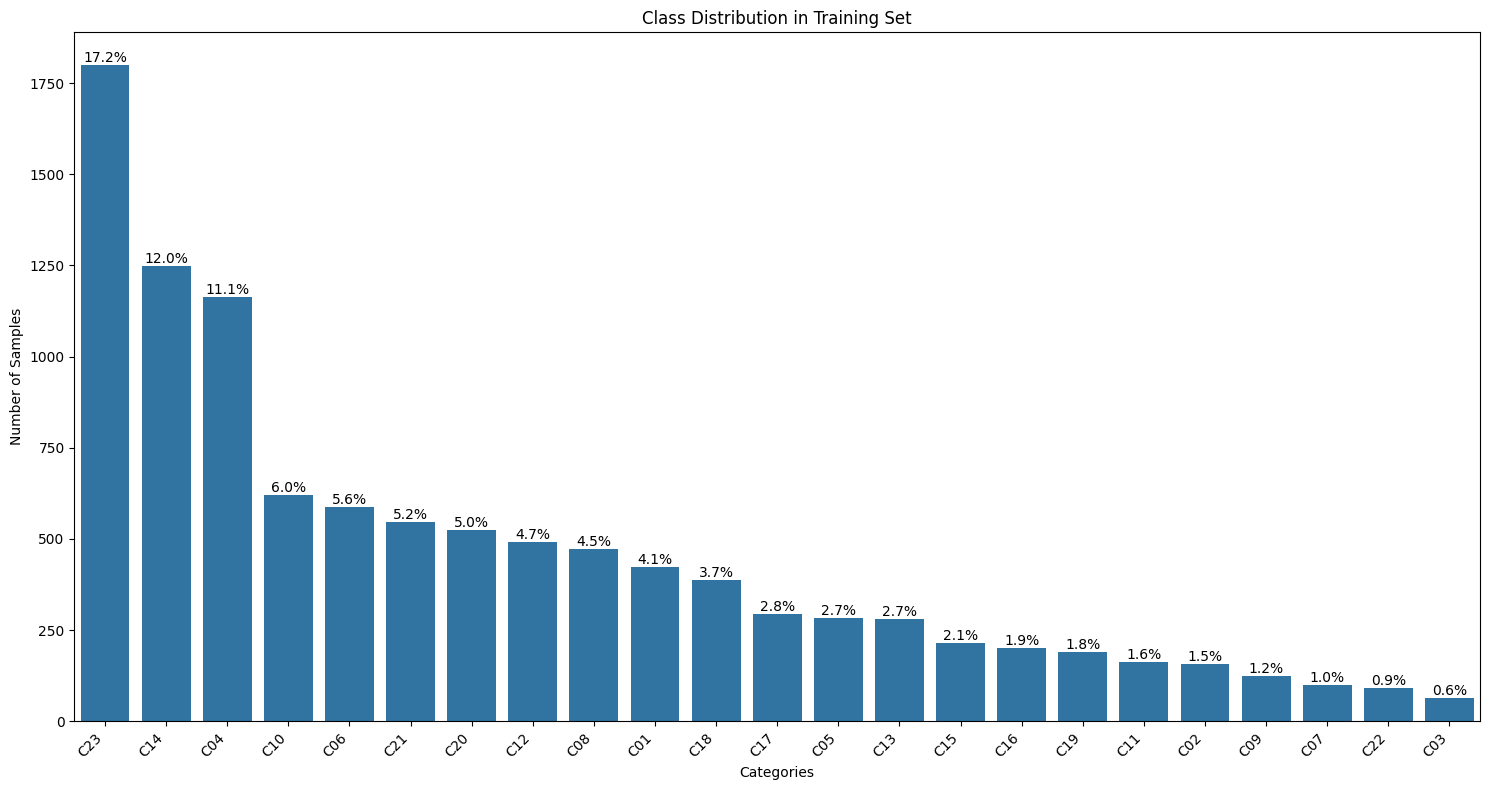


Detailed Class-wise Statistics (sorted by frequency):
--------------------------------------------------------------------------------
Class                  Count     Percentage    Cumulative %
--------------------------------------------------------------------------------
C23                      1799       17.24%       17.24%
C14                      1249       11.97%       29.21%
C04                      1163       11.15%       40.36%
C10                       621        5.95%       46.31%
C06                       588        5.64%       51.95%
C21                       546        5.23%       57.18%
C20                       525        5.03%       62.22%
C12                       491        4.71%       66.92%
C08                       473        4.53%       71.46%
C01                       423        4.05%       75.51%
C18                       388        3.72%       79.23%
C17                       295        2.83%       82.06%
C05                       283        2.71%       84

<Figure size 1000x600 with 0 Axes>

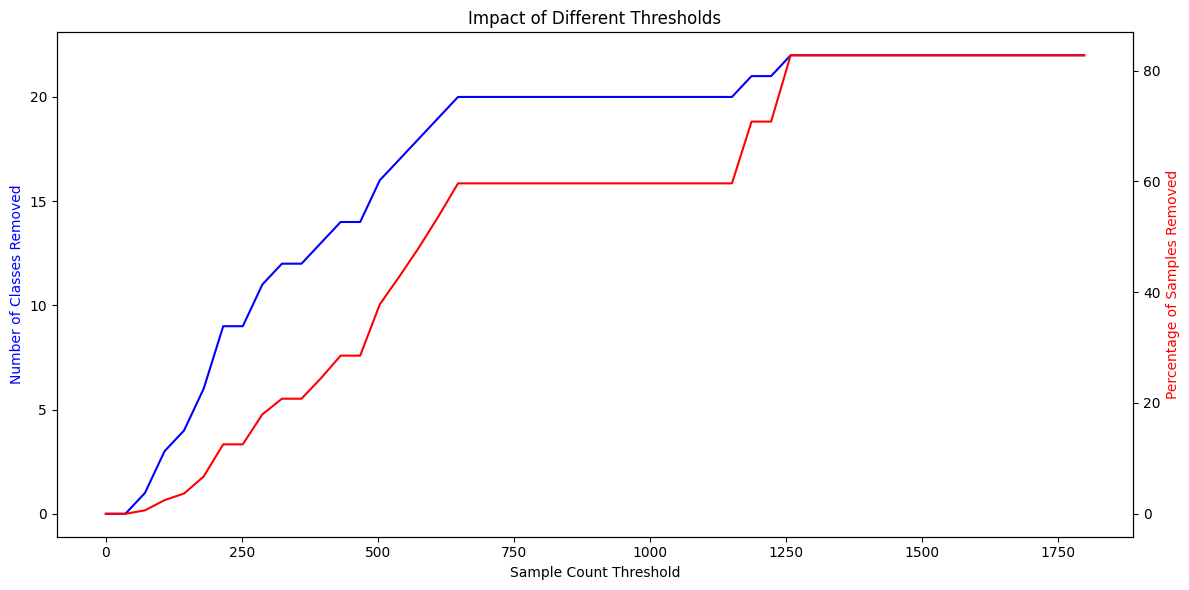

In [2]:
import torch
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

def analyze_class_distribution(train_dir: str, test_dir: str):
    """
    Analyze and visualize the class distribution in both training and test sets.
    
    Args:
        train_dir (str): Path to training data directory
        test_dir (str): Path to test data directory
    
    Returns:
        tuple: (train_distribution, test_distribution, combined_distribution)
    """
    
    def get_category_counts(data_dir):
        categories = []
        for file in Path(data_dir).glob('*.json'):
            with open(file, 'r', encoding='utf-8') as f:
                doc = json.load(f)
                if 'text' in doc and 'category' in doc and doc['text'].strip() and doc['category'].strip():
                    categories.append(doc['category'])
        return Counter(categories)
    
    # Get distributions
    train_dist = get_category_counts(train_dir)
    test_dist = get_category_counts(test_dir)
    
    # Convert to DataFrames for easier analysis
    train_df = pd.DataFrame.from_dict(train_dist, orient='index', columns=['count'])
    train_df['dataset'] = 'train'
    test_df = pd.DataFrame.from_dict(test_dist, orient='index', columns=['count'])
    test_df['dataset'] = 'test'
    
    # Create combined DataFrame
    combined_df = pd.concat([
        train_df.assign(split='train'),
        test_df.assign(split='test')
    ])
    
    # Calculate percentages
    train_df['percentage'] = train_df['count'] / train_df['count'].sum() * 100
    test_df['percentage'] = test_df['count'] / test_df['count'].sum() * 100
    
    # Sort by frequency
    train_df_sorted = train_df.sort_values('count', ascending=False)
    
    # Plotting
    plt.figure(figsize=(15, 8))
    
    # Create bar plot
    ax = sns.barplot(data=train_df_sorted, x=train_df_sorted.index, y='count')
    
    # Add percentage labels on top of each bar
    for i, v in enumerate(train_df_sorted['count']):
        ax.text(i, v, f'{train_df_sorted["percentage"].iloc[i]:.1f}%', 
                ha='center', va='bottom')
    
    plt.xticks(rotation=45, ha='right')
    plt.title('Class Distribution in Training Set')
    plt.xlabel('Categories')
    plt.ylabel('Number of Samples')
    plt.tight_layout()
    plt.show()
    
    # Print detailed class-wise statistics
    print("\nDetailed Class-wise Statistics (sorted by frequency):")
    print("-" * 80)
    print("Class                  Count     Percentage    Cumulative %")
    print("-" * 80)
    
    cumulative_percentage = 0
    for idx, (class_name, row) in enumerate(train_df_sorted.iterrows(), 1):
        cumulative_percentage += row['percentage']
        print(f"{class_name:<20} {row['count']:>8d} {row['percentage']:>11.2f}% {cumulative_percentage:>11.2f}%")
    
    print("\nClass Distribution Summary:")
    print("-" * 50)
    print(f"Total number of classes: {len(train_dist)}")
    print(f"Total training samples: {sum(train_dist.values())}")
    print(f"Average samples per class: {sum(train_dist.values())/len(train_dist):.1f}")
    print(f"Median samples per class: {train_df_sorted['count'].median():.1f}")
    
    print("\nClass balance metrics:")
    print(f"Most common class: {train_df_sorted.index[0]} ({train_df_sorted['percentage'].iloc[0]:.2f}%)")
    print(f"Least common class: {train_df_sorted.index[-1]} ({train_df_sorted['percentage'].iloc[-1]:.2f}%)")
    
    # Calculate imbalance ratio
    imbalance_ratio = train_df_sorted['count'].iloc[0] / train_df_sorted['count'].iloc[-1]
    print(f"\nImbalance ratio (majority:minority): {imbalance_ratio:.2f}:1")
    
    # Analyze and suggest thresholds
    print("\nThreshold Analysis:")
    print("-" * 80)
    percentiles = [5, 10, 15, 20, 25]
    
    for p in percentiles:
        threshold = np.percentile(train_df_sorted['count'], p)
        classes_below = train_df_sorted[train_df_sorted['count'] <= threshold]
        total_samples_removed = classes_below['count'].sum()
        percent_samples_removed = (total_samples_removed / train_df_sorted['count'].sum()) * 100
        
        print(f"\n{p}th percentile analysis:")
        print(f"Threshold: {threshold:.0f} samples")
        print(f"Classes to be removed ({len(classes_below)} classes):")
        for class_name, row in classes_below.iterrows():
            print(f"  - {class_name}: {row['count']} samples ({row['percentage']:.2f}%)")
        print(f"Total samples that would be removed: {total_samples_removed} ({percent_samples_removed:.2f}%)")
    
    # Create a second visualization showing the effect of different thresholds
    plt.figure(figsize=(10, 6))
    thresholds = np.arange(0, train_df_sorted['count'].max(), train_df_sorted['count'].max()/50)
    classes_removed = [len(train_df_sorted[train_df_sorted['count'] <= t]) for t in thresholds]
    samples_removed = [(train_df_sorted[train_df_sorted['count'] <= t]['count'].sum() / 
                       train_df_sorted['count'].sum() * 100) for t in thresholds]
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2 = ax1.twinx()
    
    ax1.plot(thresholds, classes_removed, 'b-', label='Classes Removed')
    ax2.plot(thresholds, samples_removed, 'r-', label='Samples Removed (%)')
    
    ax1.set_xlabel('Sample Count Threshold')
    ax1.set_ylabel('Number of Classes Removed', color='b')
    ax2.set_ylabel('Percentage of Samples Removed', color='r')
    
    plt.title('Impact of Different Thresholds')
    plt.tight_layout()
    plt.show()
    
    return train_df, test_df, combined_df

# Usage
if __name__ == "__main__":
    root = "processed_graphs_ohsumed"
    train_dir = "processed_data_ohsumed/train"
    test_dir = "processed_data_ohsumed/test"
    
    train_dist, test_dist, combined_dist = analyze_class_distribution(train_dir, test_dir)
    
    # Save detailed analysis to CSV
    train_dist.sort_values('count', ascending=False).to_csv('class_distribution_analysis.csv')